In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# 1. Create the XOR Dataset
# Inputs: 4 samples, 2 features
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])

# Outputs: 4 samples, 1 label (Binary Classification)
Y = np.array([[0],
              [1],
              [1],
              [0]])

print("Input Shape (X):", X.shape)
print("Output Shape (Y):", Y.shape)

Input Shape (X): (4, 2)
Output Shape (Y): (4, 1)


In [2]:
# 2. Activation Function: Sigmoid
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Derivative of Sigmoid: Used in Backpropagation
# d/dx sigmoid(x) = sigmoid(x) * (1 - sigmoid(x))
def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

# 3. Loss Function: Mean Squared Error (MSE)
def compute_loss(y_pred, y_true):
    n = y_true.shape[0]
    # MSE Formula: (1/n) * sum((pred - true)^2)
    loss = np.mean((y_pred - y_true) ** 2)
    return loss

In [3]:
# 4. Hyperparameters
learning_rate = 0.1
epochs = 10000
loss_history = []

# 5. Network Architecture
# Input Layer: 2 neurons
# Hidden Layer: 3 neurons
# Output Layer: 1 neuron

# Initialize Weights and Biases randomly
# W1: (2 input features, 3 hidden neurons)
W1 = np.random.randn(2, 3)
b1 = np.random.randn(1, 3)

# W2: (3 hidden neurons, 1 output neuron)
W2 = np.random.randn(3, 1)
b2 = np.random.randn(1, 1)

print("Weights W1 Shape:", W1.shape)
print("Weights W2 Shape:", W2.shape)

Weights W1 Shape: (2, 3)
Weights W2 Shape: (3, 1)


In [4]:
# 6. Training Loop
for epoch in range(epochs):

    # --- FORWARD PROPAGATION ---
    # Layer 1 (Hidden Layer)
    # Z1 = (X * W1) + b1
    Z1 = np.dot(X, W1) + b1
    # A1 = Activation(Z1)
    A1 = sigmoid(Z1)

    # Layer 2 (Output Layer)
    # Z2 = (A1 * W2) + b2
    Z2 = np.dot(A1, W2) + b2
    # A2 = Activation(Z2) -> This is our Prediction
    A2 = sigmoid(Z2)

    # --- COMPUTE LOSS ---
    loss = compute_loss(A2, Y)
    loss_history.append(loss)

    # --- BACKWARD PROPAGATION ---
    # We need to find gradients (dW, db) to update weights

    # Output Layer Gradients
    # dZ2 = Derivative of Loss w.r.t Z2
    # Derivative of MSE w.r.t A2 is (2/n)*(A2 - Y)
    # Chain rule: dZ2 = dLoss/dA2 * dA2/dZ2
    m = X.shape[0] # Number of samples
    dZ2 = (2/m) * (A2 - Y) * sigmoid_derivative(Z2)

    # dW2 = A1 transpose dot dZ2
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    # Hidden Layer Gradients
    # dZ1 = (dZ2 dot W2 transpose) * sigmoid_derivative(Z1)
    dZ1 = np.dot(dZ2, W2.T) * sigmoid_derivative(Z1)

    # dW1 = X transpose dot dZ1
    dW1 = np.dot(X.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # --- UPDATE PARAMETERS (Gradient Descent) ---
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    # Print loss every 1000 epochs
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

print("\nTraining Completed!")

Epoch 0, Loss: 0.2524
Epoch 1000, Loss: 0.2476
Epoch 2000, Loss: 0.2441
Epoch 3000, Loss: 0.2337
Epoch 4000, Loss: 0.2071
Epoch 5000, Loss: 0.1708
Epoch 6000, Loss: 0.1215
Epoch 7000, Loss: 0.0643
Epoch 8000, Loss: 0.0329
Epoch 9000, Loss: 0.0196

Training Completed!


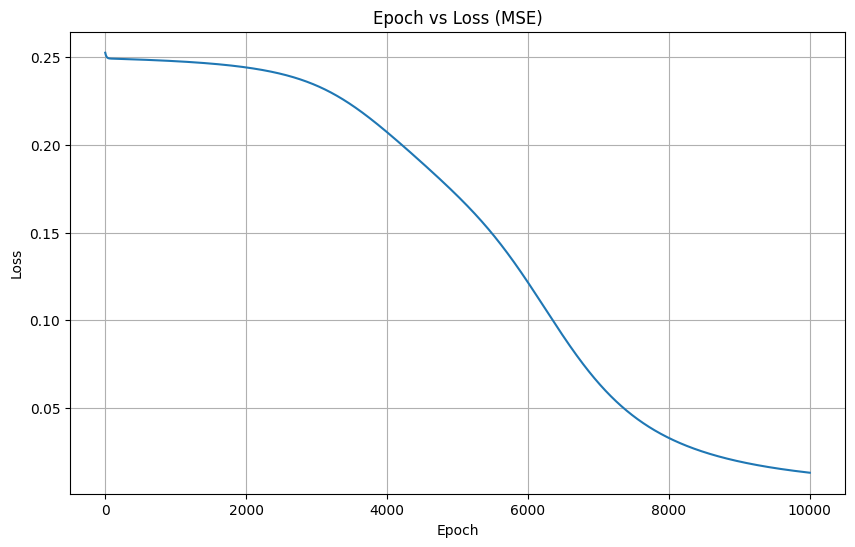


Final Predictions vs Actual:
Input: [0 0] | Actual: 0 | Predicted: 0.1028
Input: [0 1] | Actual: 1 | Predicted: 0.8734
Input: [1 0] | Actual: 1 | Predicted: 0.9025
Input: [1 1] | Actual: 0 | Predicted: 0.1288


In [5]:
# 7. Plot Epoch vs Loss
plt.figure(figsize=(10, 6))
plt.plot(loss_history)
plt.title('Epoch vs Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# 8. Final Prediction Check
print("\nFinal Predictions vs Actual:")
Z1 = np.dot(X, W1) + b1
A1 = sigmoid(Z1)
Z2 = np.dot(A1, W2) + b2
A2 = sigmoid(Z2)

for i in range(len(X)):
    print(f"Input: {X[i]} | Actual: {Y[i][0]} | Predicted: {A2[i][0]:.4f}")

/tmp/ipykernel_330/2218531998.py:34: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = patches.Circle((input_x, y), 0.4, fill=True, color='lightblue',
/tmp/ipykernel_330/2218531998.py:41: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = patches.Circle((hidden_x, y), 0.4, fill=True, color='lightgreen',
/tmp/ipykernel_330/2218531998.py:48: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = patches.Circle((output_x, y), 0.4, fill=True, color='lightcoral',


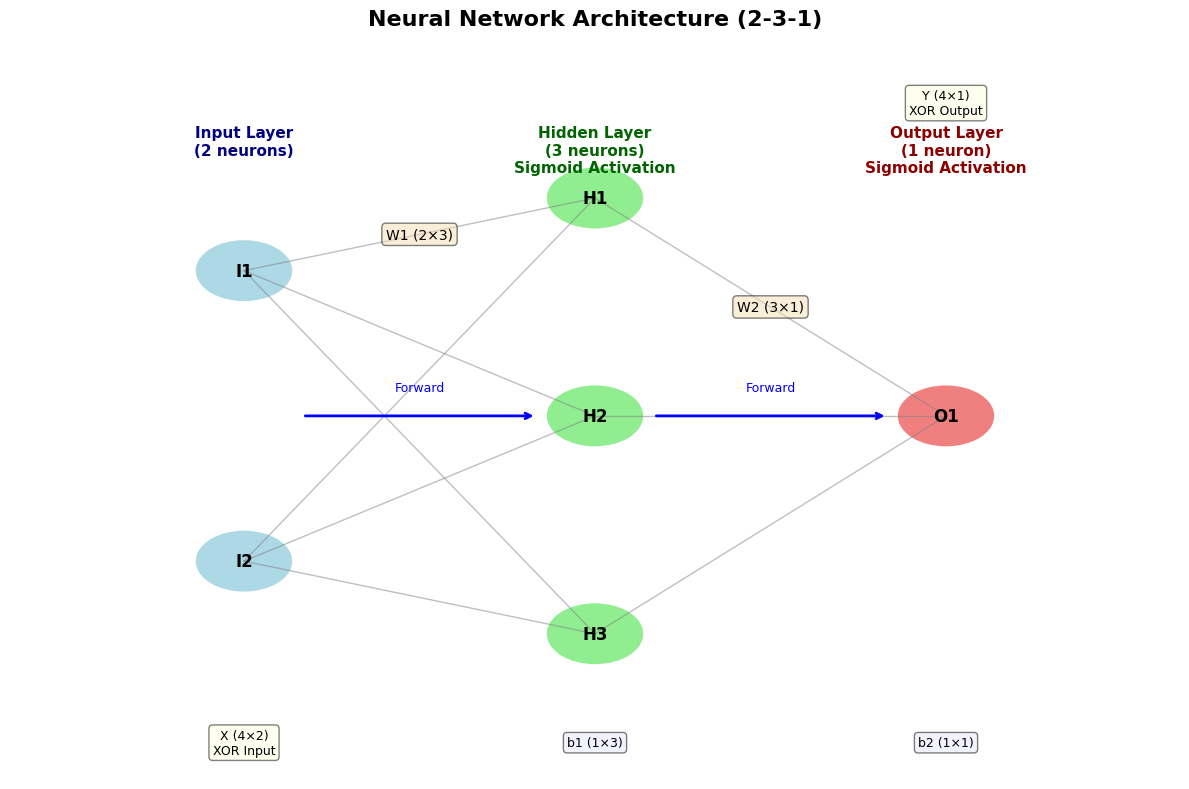

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 9. Create Neural Network Architecture Diagram
def draw_neural_network():
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    ax.set_title('Neural Network Architecture (2-3-1)', fontsize=16, fontweight='bold', pad=20)

    # Layer positions
    input_x = 2
    hidden_x = 5
    output_x = 8

    # Neuron positions (y-coordinates)
    input_y = [7, 3]      # 2 input neurons
    hidden_y = [8, 5, 2]  # 3 hidden neurons
    output_y = [5]        # 1 output neuron

    # Draw connections (Input -> Hidden)
    for i_y in input_y:
        for h_y in hidden_y:
            ax.plot([input_x, hidden_x], [i_y, h_y], 'gray', alpha=0.5, linewidth=1)

    # Draw connections (Hidden -> Output)
    for h_y in hidden_y:
        for o_y in output_y:
            ax.plot([hidden_x, output_x], [h_y, o_y], 'gray', alpha=0.5, linewidth=1)

    # Draw Input Layer neurons
    for i, y in enumerate(input_y):
        circle = patches.Circle((input_x, y), 0.4, fill=True, color='lightblue',
                                edgecolor='navy', linewidth=2)
        ax.add_patch(circle)
        ax.text(input_x, y, f'I{i+1}', ha='center', va='center', fontsize=12, fontweight='bold')

    # Draw Hidden Layer neurons
    for i, y in enumerate(hidden_y):
        circle = patches.Circle((hidden_x, y), 0.4, fill=True, color='lightgreen',
                                edgecolor='darkgreen', linewidth=2)
        ax.add_patch(circle)
        ax.text(hidden_x, y, f'H{i+1}', ha='center', va='center', fontsize=12, fontweight='bold')

    # Draw Output Layer neuron
    for i, y in enumerate(output_y):
        circle = patches.Circle((output_x, y), 0.4, fill=True, color='lightcoral',
                                edgecolor='darkred', linewidth=2)
        ax.add_patch(circle)
        ax.text(output_x, y, 'O1', ha='center', va='center', fontsize=12, fontweight='bold')

    # Layer labels
    ax.text(input_x, 9, 'Input Layer\n(2 neurons)', ha='center', va='top',
            fontsize=11, fontweight='bold', color='navy')
    ax.text(hidden_x, 9, 'Hidden Layer\n(3 neurons)\nSigmoid Activation', ha='center', va='top',
            fontsize=11, fontweight='bold', color='darkgreen')
    ax.text(output_x, 9, 'Output Layer\n(1 neuron)\nSigmoid Activation', ha='center', va='top',
            fontsize=11, fontweight='bold', color='darkred')

    # Weight labels
    ax.text(3.5, 7.5, 'W1 (2×3)', ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.text(6.5, 6.5, 'W2 (3×1)', ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # Bias labels
    ax.text(hidden_x, 0.5, 'b1 (1×3)', ha='center', va='center', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.5))
    ax.text(output_x, 0.5, 'b2 (1×1)', ha='center', va='center', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.5))

    # Input/Output labels
    ax.text(input_x, 0.5, 'X (4×2)\nXOR Input', ha='center', va='center', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))
    ax.text(output_x, 9.5, 'Y (4×1)\nXOR Output', ha='center', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

    # Add flow arrows
    ax.annotate('', xy=(4.5, 5), xytext=(2.5, 5),
                arrowprops=dict(arrowstyle='->', color='blue', lw=2))
    ax.annotate('', xy=(7.5, 5), xytext=(5.5, 5),
                arrowprops=dict(arrowstyle='->', color='blue', lw=2))

    ax.text(3.5, 5.3, 'Forward', ha='center', va='bottom', fontsize=9, color='blue')
    ax.text(6.5, 5.3, 'Forward', ha='center', va='bottom', fontsize=9, color='blue')

    plt.tight_layout()
    plt.show()

# Draw the network diagram
draw_neural_network()

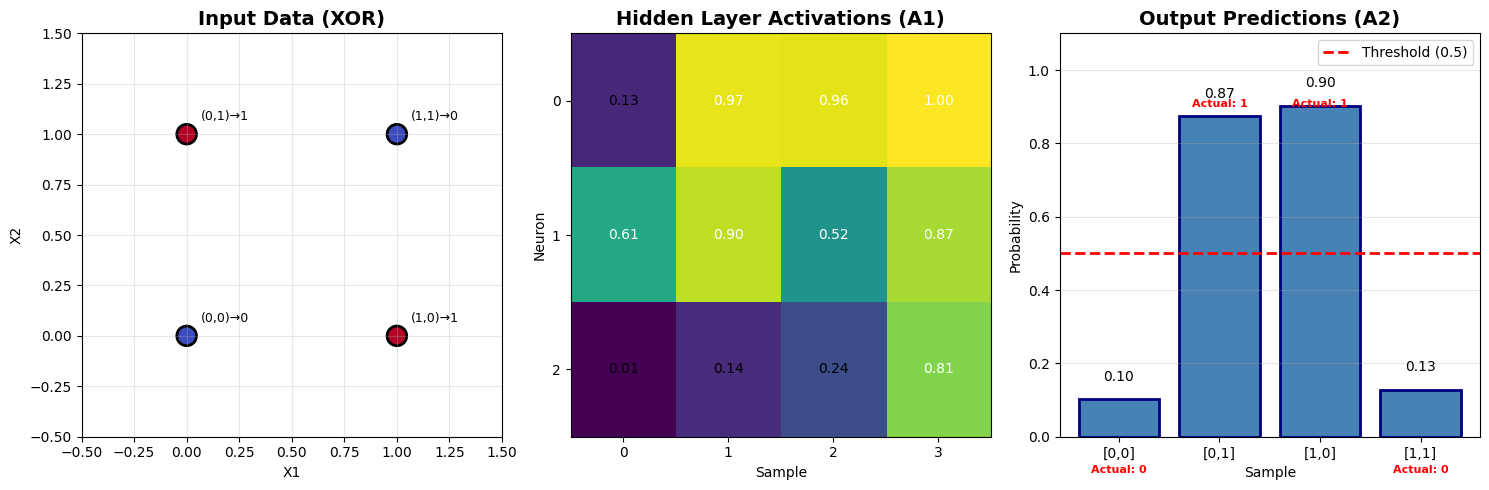

In [7]:
# 10. Data Flow Visualization
def draw_data_flow():
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Plot 1: Input Data
    axes[0].scatter(X[:, 0], X[:, 1], c=Y.flatten(), cmap='coolwarm',
                   s=200, edgecolors='black', linewidth=2)
    axes[0].set_title('Input Data (XOR)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('X1')
    axes[0].set_ylabel('X2')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(-0.5, 1.5)
    axes[0].set_ylim(-0.5, 1.5)

    # Add labels to points
    for i in range(len(X)):
        axes[0].annotate(f'({X[i][0]},{X[i][1]})→{Y[i][0]}',
                        (X[i][0], X[i][1]),
                        textcoords="offset points",
                        xytext=(10, 10),
                        fontsize=9)

    # Plot 2: Hidden Layer Activation
    Z1 = np.dot(X, W1) + b1
    A1 = sigmoid(Z1)

    axes[1].imshow(A1.T, cmap='viridis', aspect='auto')
    axes[1].set_title('Hidden Layer Activations (A1)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Sample')
    axes[1].set_ylabel('Neuron')
    axes[1].set_xticks(range(4))
    axes[1].set_yticks(range(3))

    # Add values
    for i in range(4):
        for j in range(3):
            axes[1].text(i, j, f'{A1[i][j]:.2f}', ha='center', va='center',
                        color='white' if A1[i][j] > 0.5 else 'black', fontsize=10)

    # Plot 3: Output Predictions
    axes[2].bar(range(4), A2.flatten(), color='steelblue', edgecolor='navy', linewidth=2)
    axes[2].axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Threshold (0.5)')
    axes[2].set_title('Output Predictions (A2)', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Sample')
    axes[2].set_ylabel('Probability')
    axes[2].set_xticks(range(4))
    axes[2].set_xticklabels(['[0,0]', '[0,1]', '[1,0]', '[1,1]'])
    axes[2].set_ylim(0, 1.1)
    axes[2].legend()
    axes[2].grid(True, alpha=0.3, axis='y')

    # Add actual values
    for i in range(4):
        axes[2].text(i, A2[i][0] + 0.05, f'{A2[i][0]:.2f}', ha='center', fontsize=10)
        axes[2].text(i, Y[i][0] - 0.1, f'Actual: {Y[i][0]}', ha='center',
                    fontsize=8, color='red', fontweight='bold')

    plt.tight_layout()
    plt.show()

# Draw data flow visualization
draw_data_flow()

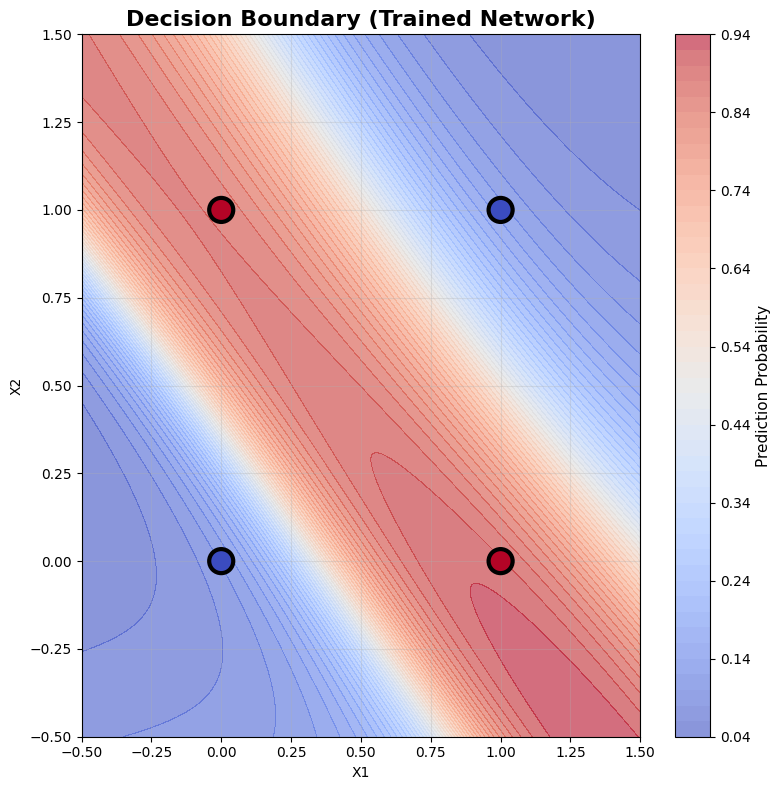

In [8]:
# 11. Decision Boundary Visualization
def draw_decision_boundary():
    fig, ax = plt.subplots(figsize=(8, 8))

    # Create mesh grid
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200),
                         np.linspace(-0.5, 1.5, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Forward pass through trained network
    Z1_grid = np.dot(grid, W1) + b1
    A1_grid = sigmoid(Z1_grid)
    Z2_grid = np.dot(A1_grid, W2) + b2
    A2_grid = sigmoid(Z2_grid)

    # Plot decision boundary
    contour = ax.contourf(xx, yy, A2_grid.reshape(xx.shape),
                         levels=50, cmap='coolwarm', alpha=0.6)

    # Plot actual data points
    scatter = ax.scatter(X[:, 0], X[:, 1], c=Y.flatten(),
                        cmap='coolwarm', s=300, edgecolors='black',
                        linewidth=3, zorder=5)

    # Add labels
    for i in range(len(X)):
        ax.annotate(f'{Y[i][0]}', (X[i][0], X[i][1]),
                   ha='center', va='center', fontsize=14,
                   fontweight='bold', color='white')

    ax.set_title('Decision Boundary (Trained Network)', fontsize=16, fontweight='bold')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.grid(True, alpha=0.3)

    # Colorbar
    cbar = plt.colorbar(contour, ax=ax)
    cbar.set_label('Prediction Probability', fontsize=11)

    plt.tight_layout()
    plt.show()

# Draw decision boundary
draw_decision_boundary()

TRAINED NETWORK PARAMETERS

📊 Input → Hidden Weights (W1): Shape (2, 3)
[[ 5.12558776 -0.35010934  3.28360106]
 [ 5.35883461  1.80228727  2.5907694 ]]

📊 Hidden Layer Biases (b1): Shape (1, 3)
[[-1.92567767  0.44319573 -4.41696633]]

📊 Hidden → Output Weights (W2): Shape (3, 1)
[[ 6.71223849]
 [-2.60639044]
 [-6.16057127]]

📊 Output Layer Biases (b2): Shape (1, 1)
[[-1.35995448]]

FINAL PERFORMANCE
Final Loss: 0.013176
Initial Loss: 0.252447
Loss Reduction: 94.78%


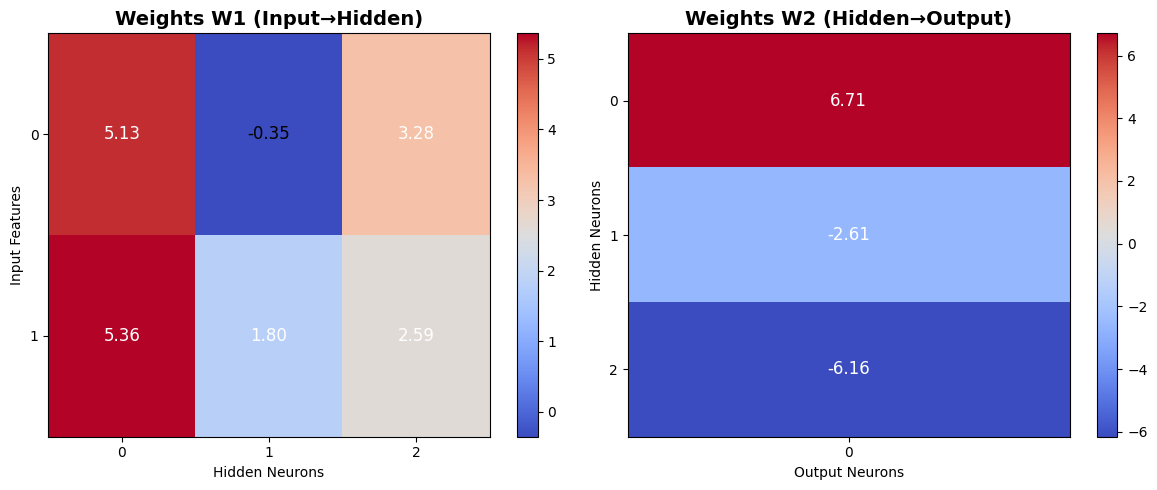

In [9]:
# 12. Weight and Bias Summary
print("="*60)
print("TRAINED NETWORK PARAMETERS")
print("="*60)

print("\n📊 Input → Hidden Weights (W1): Shape", W1.shape)
print(W1)

print("\n📊 Hidden Layer Biases (b1): Shape", b1.shape)
print(b1)

print("\n📊 Hidden → Output Weights (W2): Shape", W2.shape)
print(W2)

print("\n📊 Output Layer Biases (b2): Shape", b2.shape)
print(b2)

print("\n" + "="*60)
print("FINAL PERFORMANCE")
print("="*60)
print(f"Final Loss: {loss_history[-1]:.6f}")
print(f"Initial Loss: {loss_history[0]:.6f}")
print(f"Loss Reduction: {((loss_history[0] - loss_history[-1]) / loss_history[0] * 100):.2f}%")

# Weight visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# W1 Heatmap
im1 = axes[0].imshow(W1, cmap='coolwarm', aspect='auto')
axes[0].set_title('Weights W1 (Input→Hidden)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hidden Neurons')
axes[0].set_ylabel('Input Features')
axes[0].set_xticks(range(3))
axes[0].set_yticks(range(2))

# Add values
for i in range(2):
    for j in range(3):
        axes[0].text(j, i, f'{W1[i][j]:.2f}', ha='center', va='center',
                    color='white' if abs(W1[i][j]) > 0.5 else 'black', fontsize=12)

plt.colorbar(im1, ax=axes[0])

# W2 Heatmap
im2 = axes[1].imshow(W2, cmap='coolwarm', aspect='auto')
axes[1].set_title('Weights W2 (Hidden→Output)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Output Neurons')
axes[1].set_ylabel('Hidden Neurons')
axes[1].set_xticks(range(1))
axes[1].set_yticks(range(3))

# Add values
for i in range(3):
    for j in range(1):
        axes[1].text(j, i, f'{W2[i][j]:.2f}', ha='center', va='center',
                    color='white' if abs(W2[i][j]) > 0.5 else 'black', fontsize=12)

plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()